In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import shap

In [3]:
df = pd.read_csv("drive/MyDrive/my_project_ml_fresh/data/netflix.csv")   # <-- apna path daalo

In [4]:
df['churned'] = df['churned'].map({'Yes': 1, 'No': 0})

In [5]:
df['engagement_recency'] = (
    df['avg_watch_time_minutes'] *
    df['watch_sessions_per_week'] *
    df['binge_watch_sessions']
) / (df['days_since_last_login'] + 1)

In [8]:
features = [
    'avg_watch_time_minutes',
    'watch_sessions_per_week',
    'binge_watch_sessions',
    'engagement_recency',
    'content_interactions',
    'recommendation_click_rate'
]

X = df[features]
y = df['churned']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [11]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    eval_metric='logloss'
)

model.fit(X_train_sm, y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [28]:
y_prob = model.predict_proba(X_test)[:, 1]

threshold = 0.46# churn pakadna hai
y_pred = (y_prob > threshold).astype(int)

In [29]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[2713 5294]
 [ 679 1314]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.34      0.48      8007
           1       0.20      0.66      0.31      1993

    accuracy                           0.40     10000
   macro avg       0.50      0.50      0.39     10000
weighted avg       0.68      0.40      0.44     10000



 98%|===================| 9842/10000 [00:23<00:00]       

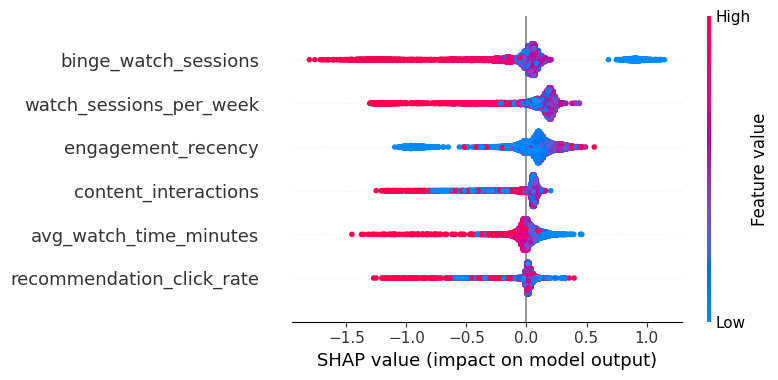

In [14]:
explainer = shap.Explainer(model, X_test)
shap_values = explainer(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

In [15]:
shap_importance = pd.DataFrame({
    'feature': X.columns,
    'mean_abs_shap': np.abs(shap_values.values).mean(axis=0)
}).sort_values(by='mean_abs_shap', ascending=False)

print(shap_importance)

                     feature  mean_abs_shap
2       binge_watch_sessions       0.239564
1    watch_sessions_per_week       0.223470
3         engagement_recency       0.186217
4       content_interactions       0.107919
0     avg_watch_time_minutes       0.070506
5  recommendation_click_rate       0.053826


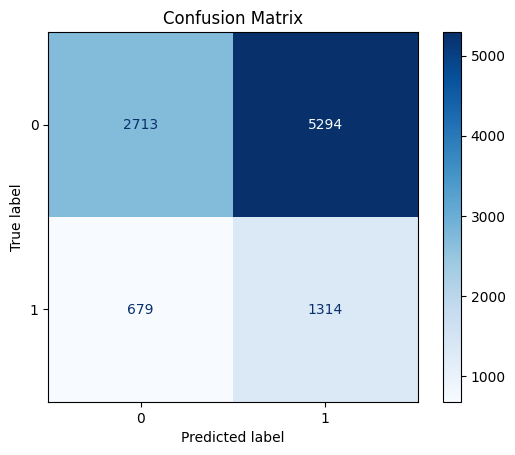

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# assuming y_test aur y_pred hai
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")  # Save as image
plt.show()